In [2]:
import gymnasium as gym 

### Demo run

In [3]:

env = gym.make("Taxi-v3",render_mode = 'human')
env.observation_space.n


for i in range(10):

    obs , info = env.reset()
    done  = False
    total_reward = 0
    
    while not done:
        
        action = env.action_space.sample()

        obs , reward , terminated , truncated , info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    print(f"Episode finished , total reward : {total_reward}")
env.close()

KeyboardInterrupt: 

In [4]:
env.close()

In [43]:
import random 
from pathlib import Path

import matplotlib.pyplot as plt 
import numpy as np


BASE_RANDOM_SEED = 58922320

def train_q_learning(
        env, 
        use_action_mask:bool = True,
        episodes : int = 5000,
        seed: int = BASE_RANDOM_SEED,
        learning_rate: float = 0.1,
        discount_factor : float = 0.95,
        epsilon: float = 0.1,
) -> dict :
    np.random.seed(seed)
    random.seed(seed)

    #initialize q table 

    n_states = env.observation_space.n 
    n_actions = env.action_space.n  
    q_table = np.zeros((n_states,n_actions))

    episode_rewards = []

    for episode in range (episodes):

        state, info = env.reset(seed = seed + episode)
        total_reward = 0
        done  = False
        truncated = False

        while not (done or truncated):
            
            action_mask  = info["action_mask"] if use_action_mask else None

            if np.random.random() < epsilon:
                if use_action_mask:
                    
                    # nonzero - return indices that are nonzero  [0] get the array from the tuple
                    
                    valid_actions = np.nonzero(action_mask == 1)[0]
                    action = np.random.choice(valid_actions)
                else: 
                    action = np.random.randint(0,n_actions)
            else:
                if use_action_mask:
                    valid_actions = np.nonzero(action_mask == 1)[0]
                    if len(valid_actions) >0 :
                        action = valid_actions[np.argmax(q_table[state,valid_actions])]
                    else:
                        action = np.random.randint(0,n_actions) 
                else:
                    action = np.argmax(q_table[state])

            next_state , reward , done , truncated , info = env.step(action)
            total_reward += reward

            # Q update

            if not(done or truncated):
                if use_action_mask:
                    next_mask = info["action_mask"]
                    valid_next_actions = np.nonzero(next_mask == 1)[0]
                    if len(valid_next_actions) > 0:
                        next_max = np.max(q_table[next_state,valid_next_actions])
                    else:
                        next_max = 0
                else:
                    next_max = np.max(q_table[next_state])

                q_table[state , action] = q_table[state , action] + learning_rate * (reward + discount_factor *next_max - q_table[state , action])

            state = next_state
        episode_rewards.append(total_reward)
    return{
        "q_table": q_table,
        "episode_rewards" : episode_rewards,
        "mean_reward" : np.mean(episode_rewards),
        "std_reward" : np.std(episode_rewards),
    }
    
    



In [ ]:
n_runs = 12
episodes = 5000
learning_rate = 0.1
discount_factor = 0.95
epsilon = 0.1

#diff seed for each run
seeds = [BASE_RANDOM_SEED + i for i in range(n_runs)]

#store results

masked_results_list = []
unmasked_results_list = []


#run 

for i, seed in enumerate(seeds):
    print(f"Run {i+1} / {n_runs} with seed {seed}")

    #train with mask
    env_masked = gym.make("Taxi-v3")
    masked_results = train_q_learning(
        env_masked,
        use_action_mask=True,
        episodes=episodes,
        seed= seed,
        learning_rate=learning_rate,
    discount_factor= discount_factor,
    epsilon= epsilon,
    )

    env_masked.close()

    masked_results_list.append(masked_results)

    #train without mask

    env_unmasked = gym.make("Taxi-v3")
    unmasked_results = train_q_learning(
        env_unmasked,
        use_action_mask=False,
        episodes=episodes,
        seed= seed,
        learning_rate=learning_rate,
    discount_factor= discount_factor,
    epsilon= epsilon,
    )
    env_unmasked.close()

    unmasked_results_list.append(unmasked_results)



Run 1 / 12 with seed 58922320
Run 2 / 12 with seed 58922321
Run 3 / 12 with seed 58922322
Run 4 / 12 with seed 58922323
Run 5 / 12 with seed 58922324
Run 6 / 12 with seed 58922325
Run 7 / 12 with seed 58922326
Run 8 / 12 with seed 58922327
Run 9 / 12 with seed 58922328
Run 10 / 12 with seed 58922329
Run 11 / 12 with seed 58922330
Run 12 / 12 with seed 58922331


In [48]:
len(masked_results_list)

12

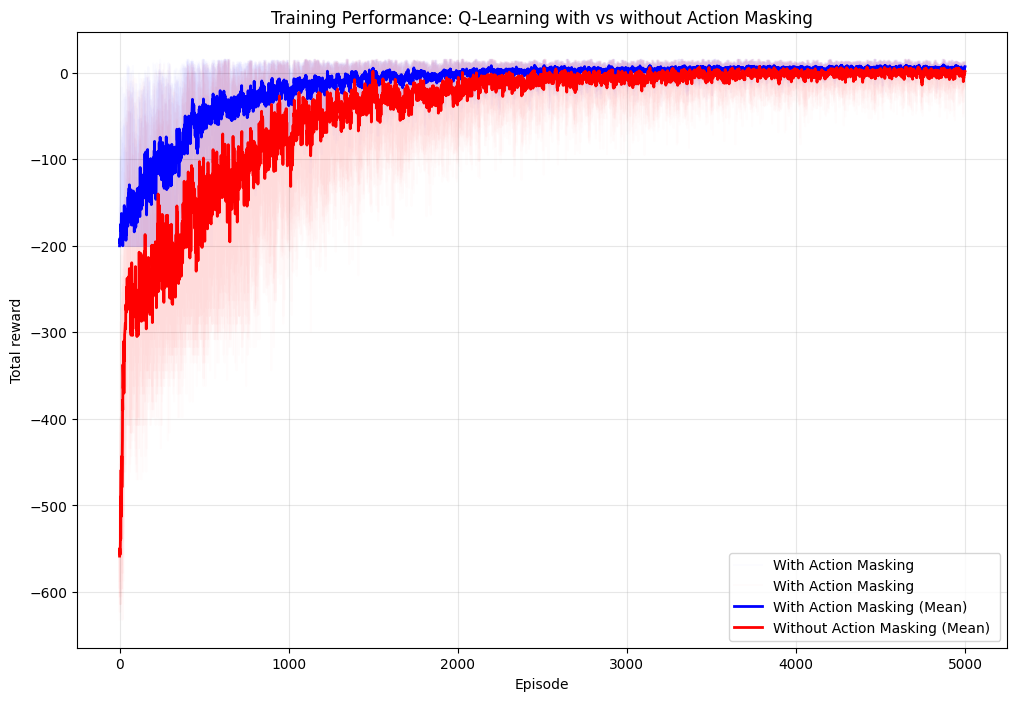

In [42]:
masked_mean_rewards = [r["mean_reward"] for r in masked_results_list]
unmasked_mean_rewards = [r["mean_reward"] for r in unmasked_results_list]


masked_overall_mean = np.mean(masked_mean_rewards)
masked_overall_std = np.std(masked_mean_rewards)
unmasked_overall_mean = np.mean(unmasked_mean_rewards)
unmasked_overall_std = np.std(unmasked_mean_rewards)

plt.figure(figsize=(12,8),dpi = 100)

for i, (masked_results , unmasked_results) in enumerate(
    zip(masked_results_list , unmasked_results_list)
):
    plt.plot(
        masked_results["episode_rewards"],
        label = "With Action Masking" if i ==0 else None,
        color = "blue",
        alpha= 0.01,
    )
    plt.plot(
        unmasked_results["episode_rewards"],
        label = "With Action Masking" if i ==0 else None,
        color = "red",
        alpha= 0.01,
    )

masked_mean_curve = np.mean([r["episode_rewards"] for r in masked_results_list] , axis = 0)
unmasked_mean_curve = np.mean([r["episode_rewards"] for r in unmasked_results_list] , axis = 0)

plt.plot(masked_mean_curve , label = "With Action Masking (Mean) " , color = "blue", linewidth = 2)

plt.plot(unmasked_mean_curve , label = "Without Action Masking (Mean) " , color = "red", linewidth = 2)

plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Training Performance: Q-Learning with vs without Action Masking")
plt.legend()
plt.grid(True,alpha = 0.3)
plt.show()







In [ ]:
import numpy as np
import random
import gymnasium as gym # Using modern gymnasium
from tqdm import tqdm

class taxi_agent:
    def __init__(
        self,
        seed: int,
        learning_rate: float,
        discount_factor: float,
        initial_epsilon: float,
        final_epsilon: float,
        env_name: str = "Taxi-v3",
    ):
        self.env = gym.make(env_name)
        self.lr = learning_rate
        self.dis_f = discount_factor
        self.epsilon = initial_epsilon
        self.final_epsilon = final_epsilon
        self.epsilon_decay = 0.0 # Will be set in train()

        self.n_states = self.env.observation_space.n
        self.n_actions = self.env.action_space.n 
        self.q_table = np.zeros((self.n_states, self.n_actions))

        self.training_error = []
        
        # Seed both the environment and random libraries
        self.env.reset(seed=seed)
        np.random.seed(seed)
        random.seed(seed)
    
    def get_action(self, state, info):
        # Apply action mask to prevent illegal moves (like hitting walls)
        action_mask = info["action_mask"] 
        valid_actions = np.nonzero(action_mask == 1)[0]
        
        if np.random.random() < self.epsilon:
            return np.random.choice(valid_actions)
        else:
            # Exploit: choose best action among valid ones
            return valid_actions[np.argmax(self.q_table[state, valid_actions])]
    
    def update(self, state, action, next_info, reward, terminated, next_state):
        action_mask = next_info["action_mask"] 
        next_valid_actions = np.nonzero(action_mask == 1)[0]

        # Q-Learning Target: reward + gamma * max(Q(s', a'))
        if terminated:
            target = reward
        else:
            future_q_values = np.max(self.q_table[next_state, next_valid_actions])
            target = reward + self.dis_f * future_q_values 

        diff = target - self.q_table[state, action]
        self.q_table[state, action] += self.lr * diff
        self.training_error.append(diff)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

    def train(self, n_episodes):
        # Calculate decay rate to reach final_epsilon halfway through training
        self.epsilon_decay = (self.epsilon - self.final_epsilon) / (n_episodes / 2)
        
        for episode in tqdm(range(n_episodes)):
            state, info = self.env.reset()
            done = False

            while not done:
                action = self.get_action(state, info)
                next_state, reward, terminated, truncated, next_info = self.env.step(action)
                
                self.update(state, action, next_info, reward, terminated, next_state)
                
                state = next_state
                info = next_info
                done = terminated or truncated
                
            self.decay_epsilon()
        self.env.close()

# Execution
agent = taxi_agent(
    seed=100100,
    learning_rate=0.1,
    discount_factor=0.95,
    initial_epsilon=0.95,
    final_epsilon=0.01 
)

agent.train(n_episodes=5000)